# Unified Research Notebook: Physical-Neural Facial Inverse Rendering

This single notebook contains the full project workflow:

1. Load a face photo or synthetic fallback
2. Run physical-only inverse rendering
3. Run physical + neural residual reconstruction
4. Show decomposition outputs, metrics, graphs, relighting, and novel views
5. Run a Mitsuba 3 / Dr.Jit differentiable-rendering proof experiment
6. Save all outputs for report/demo use


## 1. Environment and Package Check

In [1]:
from pathlib import Path
import importlib
import os
import subprocess
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent

os.environ.setdefault("MPLCONFIGDIR", str((REPO_ROOT / "outputs" / "mpl_cache").resolve()))
os.environ.setdefault("XDG_CACHE_HOME", str((REPO_ROOT / "outputs" / "cache").resolve()))
(REPO_ROOT / "outputs" / "mpl_cache").mkdir(parents=True, exist_ok=True)
(REPO_ROOT / "outputs" / "cache").mkdir(parents=True, exist_ok=True)

# Dr.Jit writes a JIT cache under HOME. Keep it inside the project for notebook reliability.
os.environ.setdefault("HOME", str((REPO_ROOT / ".cache_home").resolve()))
(REPO_ROOT / ".cache_home" / ".drjit").mkdir(parents=True, exist_ok=True)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

required_modules = {
    "torch": "torch",
    "numpy": "numpy",
    "cv2": "opencv-python",
    "imageio": "imageio",
    "matplotlib": "matplotlib",
    "skimage": "scikit-image",
}

missing_packages = []
for module_name, package_name in required_modules.items():
    try:
        importlib.import_module(module_name)
        print(f"OK: {module_name}")
    except Exception:
        print(f"Missing: {module_name}")
        missing_packages.append(package_name)

if missing_packages:
    missing = ", ".join(missing_packages)
    raise RuntimeError(
        "This notebook kernel is missing required packages: " + missing + "\n\n"
        "Run these commands in Terminal, then restart Jupyter from the project venv:\n"
        f"cd {REPO_ROOT}\n"
        "python3 -m venv .venv\n"
        "source .venv/bin/activate\n"
        "pip install -e '.[render]'\n"
        "HOME=\"$PWD/.cache_home\" jupyter notebook\n"
    )

print(f"Repository root: {REPO_ROOT}")

OK: torch
OK: numpy
OK: cv2
OK: imageio
OK: matplotlib
OK: skimage
Repository root: /Users/bhuvaneshperumal/Desktop/phys-neural-face-decomposition


## 2. Imports

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Image, Markdown, SVG, display

from src.config import ExperimentConfig
from src.evaluation.diagnostics import export_research_diagnostics, write_ablation_report
from src.evaluation.visualization import save_gif, save_image_grid
from src.pipeline import FaceDecompositionPipeline
from src.training.datasets import SyntheticFaceDataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
from src.optimization.mitsuba_inverse import (
    MitsubaInverseConfig,
    mitsuba_drjit_available,
    run_mitsuba_inverse_experiment,
)


Matplotlib is building the font cache; this may take a moment.


Using device: cpu


## 3. Experiment Settings

Set `IMAGE_PATH` to your photo. If it does not exist, the notebook uses the synthetic sample so every cell still runs.

In [18]:
IMAGE_PATH = REPO_ROOT / "data" / "your_face.jpg"
OUTPUT_DIR = REPO_ROOT / "outputs" / "notebook_research_run"
ITERATIONS = 8

USE_SYNTHETIC = not IMAGE_PATH.exists()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Image path: {IMAGE_PATH}")
print(f"Using synthetic input: {USE_SYNTHETIC}")
print(f"Output directory: {OUTPUT_DIR}")

Image path: /Users/bhuvaneshperumal/Desktop/phys-neural-face-decomposition/data/your_face.jpg
Using synthetic input: False
Output directory: /Users/bhuvaneshperumal/Desktop/phys-neural-face-decomposition/outputs/notebook_research_run


## 4. Raw Input Preview

This shows the image before face detection, cropping, background removal, or masking.

### Raw Input Photo

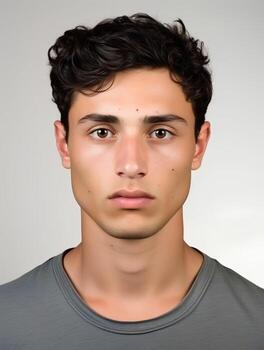

In [19]:
from IPython.display import Image, Markdown, display
from src.evaluation.visualization import save_image_grid
from src.training.datasets import SyntheticFaceDataset

if USE_SYNTHETIC:
    preview_sample = SyntheticFaceDataset(length=1)[0]
    raw_preview_path = save_image_grid(
        OUTPUT_DIR / "raw_input_preview.png",
        [preview_sample["image"]],
        nrow=1,
    )
    display(Markdown("### Raw Synthetic Input"))
    display(Image(filename=str(raw_preview_path)))
else:
    display(Markdown("### Raw Input Photo"))
    display(Image(filename=str(IMAGE_PATH)))


## 5. Configure Pipeline

In [20]:
config = ExperimentConfig()
config.metadata.run_dir = OUTPUT_DIR
config.renderer.image_size = (256, 256)
config.optimization.iterations = ITERATIONS
config.optimization.snapshot_every = max(1, ITERATIONS // 4)
config.metadata.face_prior_backend = "synthetic"
config.training.checkpoint_dir = OUTPUT_DIR / "checkpoints"
config.training.log_dir = OUTPUT_DIR / "logs"
config.save(OUTPUT_DIR / "config.json")

pipeline = FaceDecompositionPipeline(config=config, device=device)
print(json.dumps(config.to_dict(), indent=2, default=str)[:1200])

{
  "metadata": {
    "name": "physical-neural-face-decomposition",
    "run_dir": "/Users/bhuvaneshperumal/Desktop/phys-neural-face-decomposition/outputs/notebook_research_run",
    "seed": 42,
    "device": "auto",
    "description": "",
    "tags": [],
    "resume_from": null,
    "face_prior_backend": "synthetic",
    "face_prior_model_path": null
  },
  "renderer": {
    "image_size": [
      256,
      256
    ],
    "background_color": [
      0.0,
      0.0,
      0.0
    ],
    "clamp_output": true,
    "use_soft_mask": true,
    "epsilon": 1e-06
  },
  "optimization": {
    "iterations": 8,
    "lr_geometry": 0.02,
    "lr_albedo": 0.02,
    "lr_lighting": 0.02,
    "lr_residual": 0.0001,
    "reconstruction_weight": 1.0,
    "perceptual_weight": 0.5,
    "lighting_regularization_weight": 0.005,
    "albedo_smoothness_weight": 0.01,
    "depth_smoothness_weight": 0.01,
    "residual_weight": 0.2,
    "use_residual_model": false,
    "snapshot_every": 2
  },
  "training": {
  

## 5. Load Input and Preview Mask

### Preprocessed Input and Mask

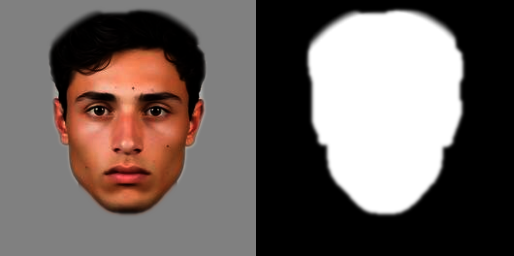

{'face_bbox_detected': True,
 'face_bbox_source': 'opencv_haar',
 'background_removed': True,
 'background_removal_method': 'opencv_grabcut',
 'padding': 0.35}

In [21]:
from IPython.display import Image, Markdown, display
from src.evaluation.visualization import save_image_grid
from src.training.datasets import SyntheticFaceDataset

if USE_SYNTHETIC:
    sample = SyntheticFaceDataset(length=1)[0]
    target = sample["image"].to(pipeline.device)
    mask = sample["mask"].to(pipeline.device)
    metadata = {"source": "synthetic"}
    prior = pipeline.face_prior_backend.estimate(target, mask=mask)
else:
    target, mask, metadata, prior = pipeline.preprocess_input(IMAGE_PATH)

(OUTPUT_DIR / "input_metadata.json").write_text(json.dumps(metadata, indent=2, sort_keys=True, default=str))
initial_state = prior.to_face_state(target, mask=mask, device=pipeline.device)

preview_mask = mask.detach().cpu()
if preview_mask.ndim == 4:
    preview_mask = preview_mask.squeeze(0)
if preview_mask.shape[0] == 1:
    preview_mask = preview_mask.repeat(3, 1, 1)

preprocessed_path = save_image_grid(
    OUTPUT_DIR / "preprocessed_input.png",
    [target.detach().cpu(), preview_mask],
    nrow=2,
)

display(Markdown("### Preprocessed Input and Mask"))
display(Image(filename=str(preprocessed_path)))
metadata


## 6. Phase 1: Physical-Only Inverse Rendering

In [22]:
phase1 = pipeline.run_phase1(
    target,
    mask=mask,
    num_iterations=ITERATIONS,
    initial_state=initial_state,
)
phase1_relighting = pipeline.relight(phase1, mask=mask)
phase1_novel_views = pipeline.novel_view_sweep(phase1, mask=mask)
phase1_dir = OUTPUT_DIR / "phase1"
pipeline.save_phase_outputs(
    phase1_dir,
    result=phase1,
    target_image=target,
    relighting=phase1_relighting,
    novel_views=phase1_novel_views,
)
phase1_summary = export_research_diagnostics(
    phase1_dir / "diagnostics",
    phase_name="phase1_physical_only",
    result=phase1,
    target_image=target,
    mask=mask,
)
phase1_summary.metrics

{'psnr': 7.950318336486816, 'ssim': 0.3162861764431, 'lpips': -1.0}

## 7. Phase 1 Diagnostics

### Decomposition Grid: Target | Physical | Prediction | Albedo | Shading | Depth | Normals | Error

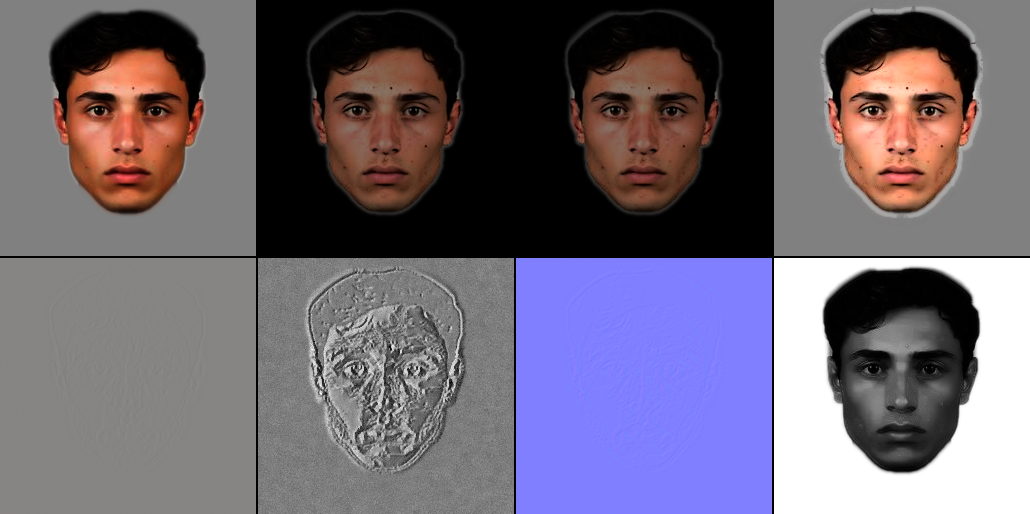

### Loss Curves

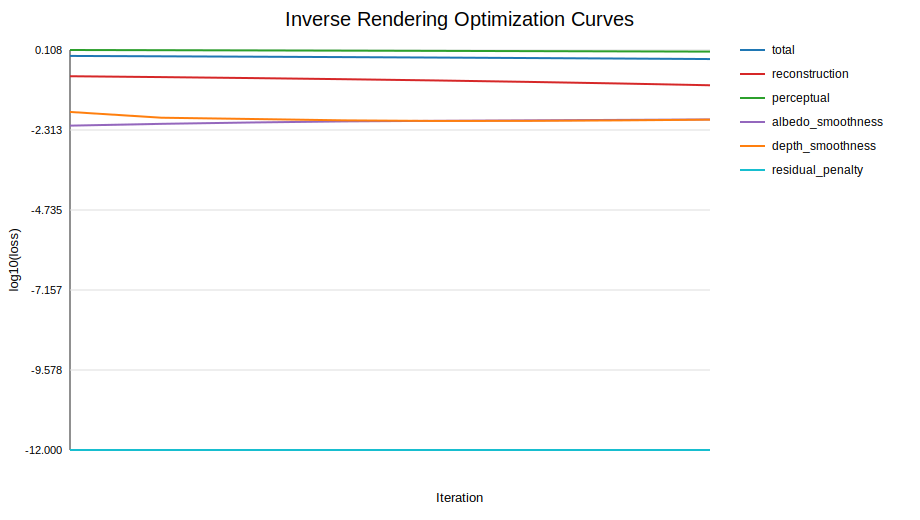

### Lighting Coefficients

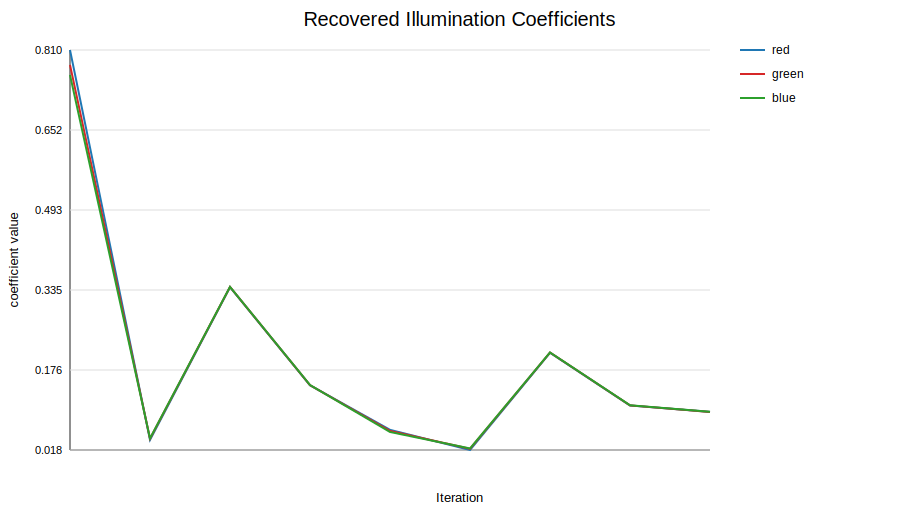

In [23]:
display(Markdown("### Decomposition Grid: Target | Physical | Prediction | Albedo | Shading | Depth | Normals | Error"))
display(Image(filename=str(phase1_dir / "diagnostics" / "decomposition_grid.png")))
display(Markdown("### Loss Curves"))
display(SVG(filename=str(phase1_dir / "diagnostics" / "loss_curves.svg")))
display(Markdown("### Lighting Coefficients"))
display(SVG(filename=str(phase1_dir / "diagnostics" / "lighting_coefficients.svg")))

## 8. Phase 2: Physical + Neural Residual

In [24]:
phase2 = pipeline.run_phase2(
    target,
    mask=mask,
    num_iterations=ITERATIONS,
    initial_state=phase1.state,
)
phase2_relighting = pipeline.relight(phase2, mask=mask)
phase2_novel_views = pipeline.novel_view_sweep(phase2, mask=mask)
phase2_dir = OUTPUT_DIR / "phase2"
pipeline.save_phase_outputs(
    phase2_dir,
    result=phase2,
    target_image=target,
    relighting=phase2_relighting,
    novel_views=phase2_novel_views,
)
phase2_summary = export_research_diagnostics(
    phase2_dir / "diagnostics",
    phase_name="phase2_physical_neural",
    result=phase2,
    target_image=target,
    mask=mask,
)
phase2_summary.metrics

{'psnr': 11.945547103881836, 'ssim': 0.296064168214798, 'lpips': -1.0}

## 9. Phase 2 Diagnostics

### Decomposition Grid

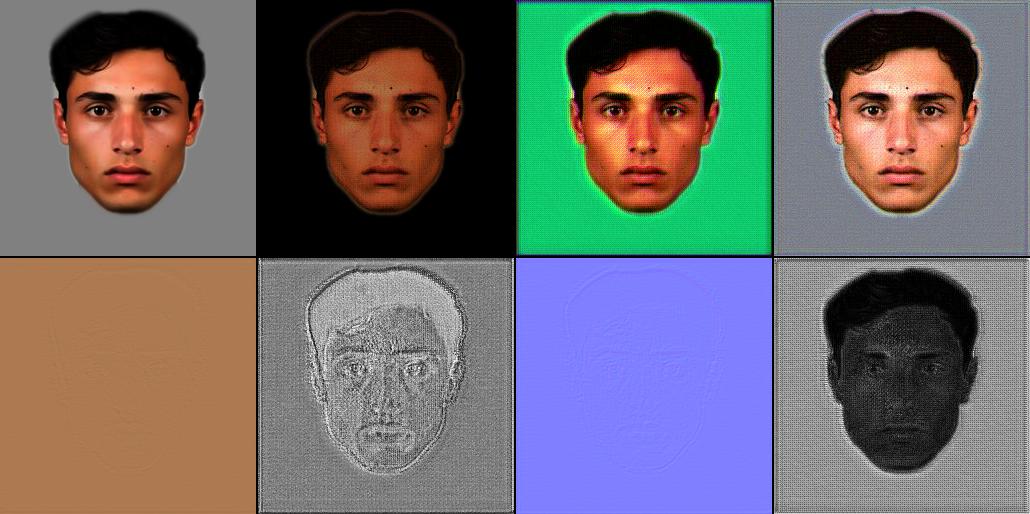

### Neural Residual Magnitude

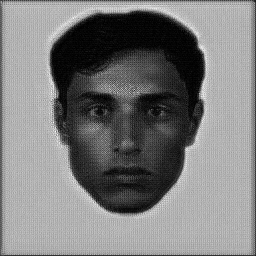

### Loss Curves

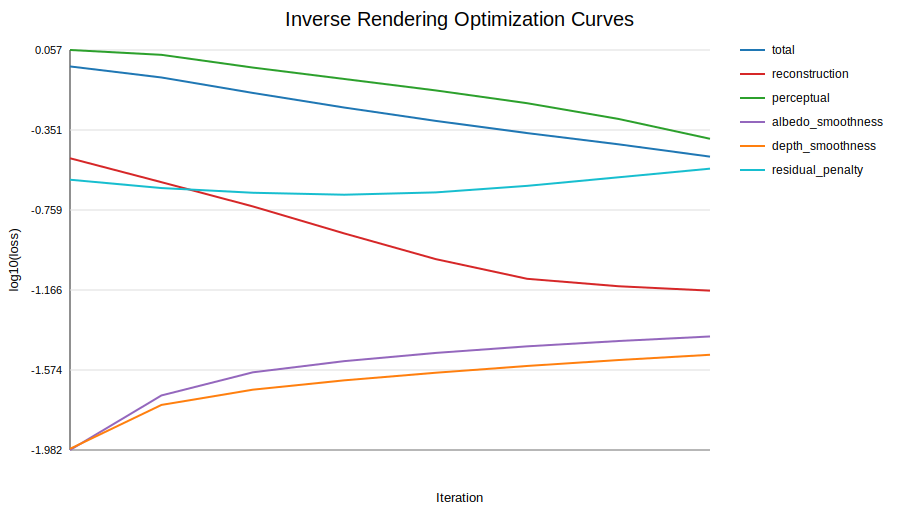

### Lighting Coefficients

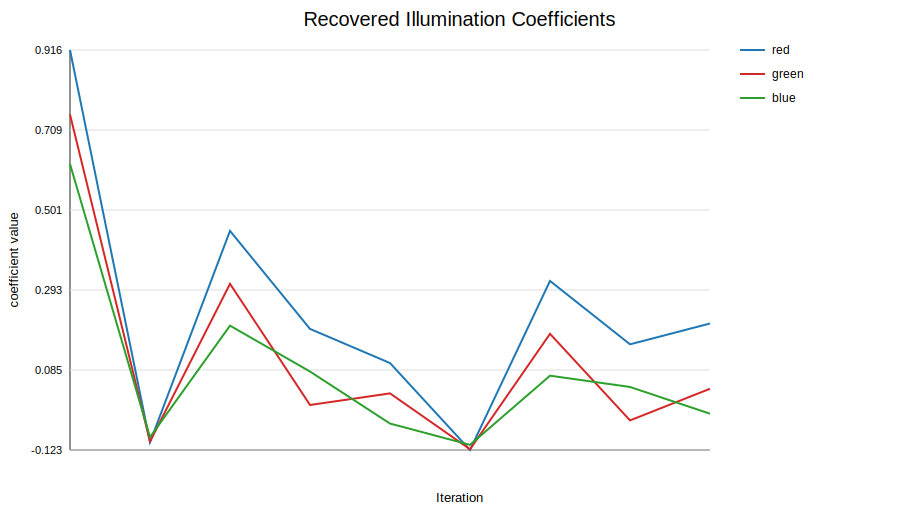

In [25]:
display(Markdown("### Decomposition Grid"))
display(Image(filename=str(phase2_dir / "diagnostics" / "decomposition_grid.png")))
display(Markdown("### Neural Residual Magnitude"))
display(Image(filename=str(phase2_dir / "diagnostics" / "residual_map.png")))
display(Markdown("### Loss Curves"))
display(SVG(filename=str(phase2_dir / "diagnostics" / "loss_curves.svg")))
display(Markdown("### Lighting Coefficients"))
display(SVG(filename=str(phase2_dir / "diagnostics" / "lighting_coefficients.svg")))

## 10. Relighting and Novel-View Outputs

### Relighting Presets

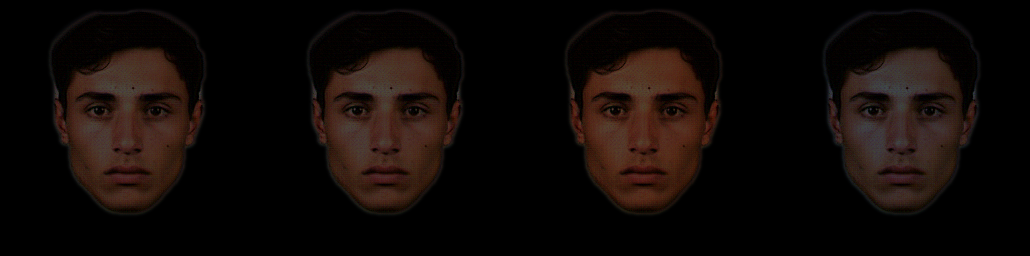

### Limited Novel Views

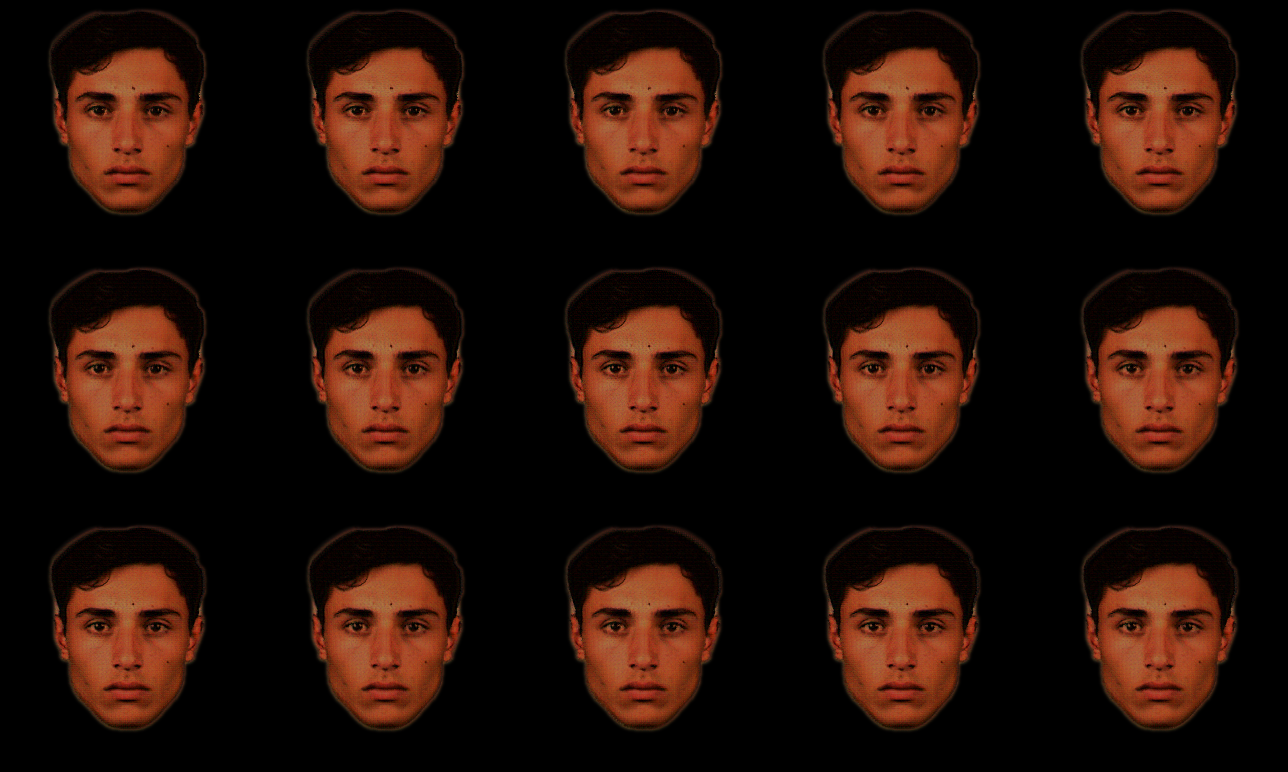

In [26]:
phase2_relight_grid = save_image_grid(
    OUTPUT_DIR / "phase2_relighting_grid.png",
    [render.image.detach().cpu().squeeze(0) for render in phase2_relighting.values()],
    nrow=len(phase2_relighting),
)
phase2_novel_grid = save_image_grid(
    OUTPUT_DIR / "phase2_novel_view_grid.png",
    [render.image.detach().cpu().squeeze(0) for render in phase2_novel_views.values()],
    nrow=5,
)

display(Markdown("### Relighting Presets"))
display(Image(filename=str(phase2_relight_grid)))
display(Markdown("### Limited Novel Views"))
display(Image(filename=str(phase2_novel_grid)))

## 11. Ablation Summary and Component Statistics

In [27]:
ablation_path = write_ablation_report(OUTPUT_DIR / "ablation_summary.md", [phase1_summary, phase2_summary])
display(Markdown(ablation_path.read_text()))

stats = json.loads((phase2_dir / "diagnostics" / "component_statistics.json").read_text())
for name, values in stats.items():
    print(
        f"{name:18s} mean={values['mean']:+.5f} std={values['std']:.5f} "
        f"min={values['minimum']:+.5f} max={values['maximum']:+.5f}"
    )

# Ablation Summary

| Phase | PSNR | SSIM | LPIPS |
| --- | ---: | ---: | ---: |
| phase1_physical_only | 7.950318 | 0.316286 | -1.000000 |
| phase2_physical_neural | 11.945547 | 0.296064 | -1.000000 |

## Delta

- PSNR change: 3.995229
- SSIM change: -0.020222


albedo             mean=+0.46922 std=0.21042 min=+0.00000 max=+1.00000
depth              mean=+0.00626 std=0.05726 min=-0.25493 max=+0.24739
lighting           mean=+0.14303 std=0.27063 min=-0.12279 max=+0.91643
mask               mean=+0.37934 std=0.47566 min=+0.00000 max=+1.00000
physical_image     mean=+0.08006 std=0.16211 min=+0.00000 max=+0.71038
prediction         mean=+0.37222 std=0.30750 min=+0.00000 max=+1.00000
residual           mean=+0.29216 std=0.29582 min=-0.27132 max=+1.00000


## 12. Analytical Graphs

These plots make the notebook look and read more like a research artifact: optimization traces and metric comparison between physical-only and physical+neural decomposition.

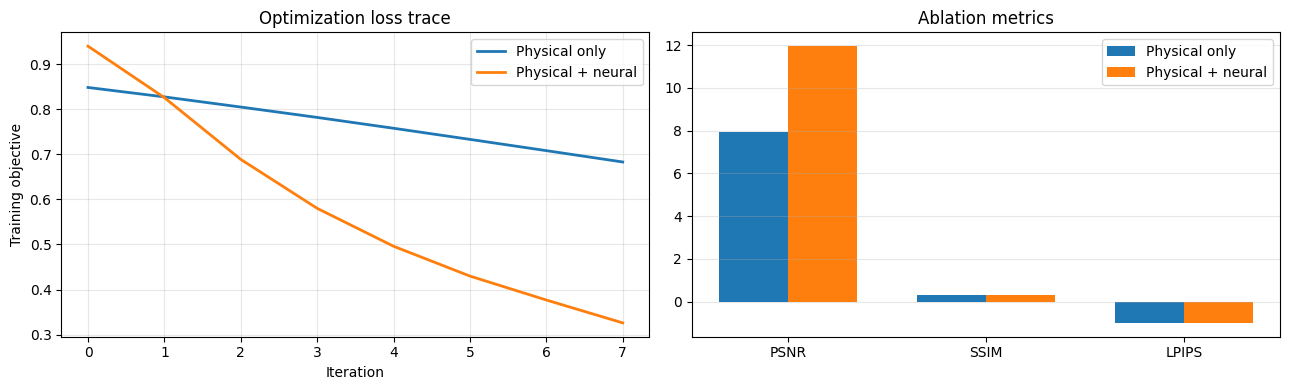

In [28]:
phase1_losses = phase1.history.total
phase2_losses = phase2.history.total

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(phase1_losses, label="Physical only", linewidth=2)
axes[0].plot(phase2_losses, label="Physical + neural", linewidth=2)
axes[0].set_title("Optimization loss trace")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Training objective")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

metric_names = ["psnr", "ssim", "lpips"]
phase1_values = [phase1_summary.metrics.get(name, 0.0) for name in metric_names]
phase2_values = [phase2_summary.metrics.get(name, 0.0) for name in metric_names]
x = np.arange(len(metric_names))
width = 0.35
axes[1].bar(x - width / 2, phase1_values, width, label="Physical only")
axes[1].bar(x + width / 2, phase2_values, width, label="Physical + neural")
axes[1].set_title("Ablation metrics")
axes[1].set_xticks(x)
axes[1].set_xticklabels([name.upper() for name in metric_names])
axes[1].grid(True, axis="y", alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()


## 13. Mitsuba 3 / Dr.Jit Differentiable Renderer Experiment

This section directly addresses the differentiable-rendering requirement. It loads a Mitsuba scene, traverses differentiable parameters, deliberately perturbs albedo and illumination, and optimizes them back toward a target render using Dr.Jit gradients.

For stability, the main notebook optimizes **albedo + illumination first**. Geometry keys are still traversed and reported, but geometry optimization is intentionally disabled here because unconstrained vertex optimization from a single image is much less stable without a FLAME/3DMM prior.


In [29]:
import importlib
import src.optimization.mitsuba_inverse as mitsuba_inverse_module

mitsuba_inverse_module = importlib.reload(mitsuba_inverse_module)
MitsubaInverseConfig = mitsuba_inverse_module.MitsubaInverseConfig
mitsuba_drjit_available = mitsuba_inverse_module.mitsuba_drjit_available
run_mitsuba_inverse_experiment = mitsuba_inverse_module.run_mitsuba_inverse_experiment

MITSUBA_OUTPUT_DIR = OUTPUT_DIR / "mitsuba_drjit"
print("Mitsuba/Dr.Jit available:", mitsuba_drjit_available())

mitsuba_config = MitsubaInverseConfig(
    output_dir=MITSUBA_OUTPUT_DIR,
    iterations=24,
    spp=8,
    evaluation_spp=16,
    image_size=(96, 96),
    learning_rate=0.03,
    optimize_geometry=False,
    optimize_albedo=True,
    optimize_light=True,
)

mitsuba_summary = run_mitsuba_inverse_experiment(mitsuba_config)
mitsuba_payload = mitsuba_summary.to_dict()
print(json.dumps(mitsuba_payload, indent=2, sort_keys=True, default=str))


Mitsuba/Dr.Jit available: True
{
  "artifacts": {
    "final_exr": "/Users/bhuvaneshperumal/Desktop/phys-neural-face-decomposition/outputs/notebook_research_run/mitsuba_drjit/optimized.exr",
    "initial_exr": "/Users/bhuvaneshperumal/Desktop/phys-neural-face-decomposition/outputs/notebook_research_run/mitsuba_drjit/initial.exr",
    "scene_xml": "/Users/bhuvaneshperumal/Desktop/phys-neural-face-decomposition/outputs/notebook_research_run/mitsuba_drjit/scene/mitsuba_face_inverse.xml",
    "target_exr": "/Users/bhuvaneshperumal/Desktop/phys-neural-face-decomposition/outputs/notebook_research_run/mitsuba_drjit/target.exr"
  },
  "diagnostics": {
    "absolute_mse_reduction": 0.00023675154261582065,
    "final_eval_mse": 2.0327510355855338e-05,
    "initial_eval_mse": 0.000257079052971676,
    "relative_mse_reduction": 0.9209289511499213
  },
  "losses": [
    0.0002608742215670645,
    0.0002403395192231983,
    0.00022077708854340017,
    0.00020220427541062236,
    0.000184632866876199

## 14. Mitsuba Render Outputs and Loss Curve

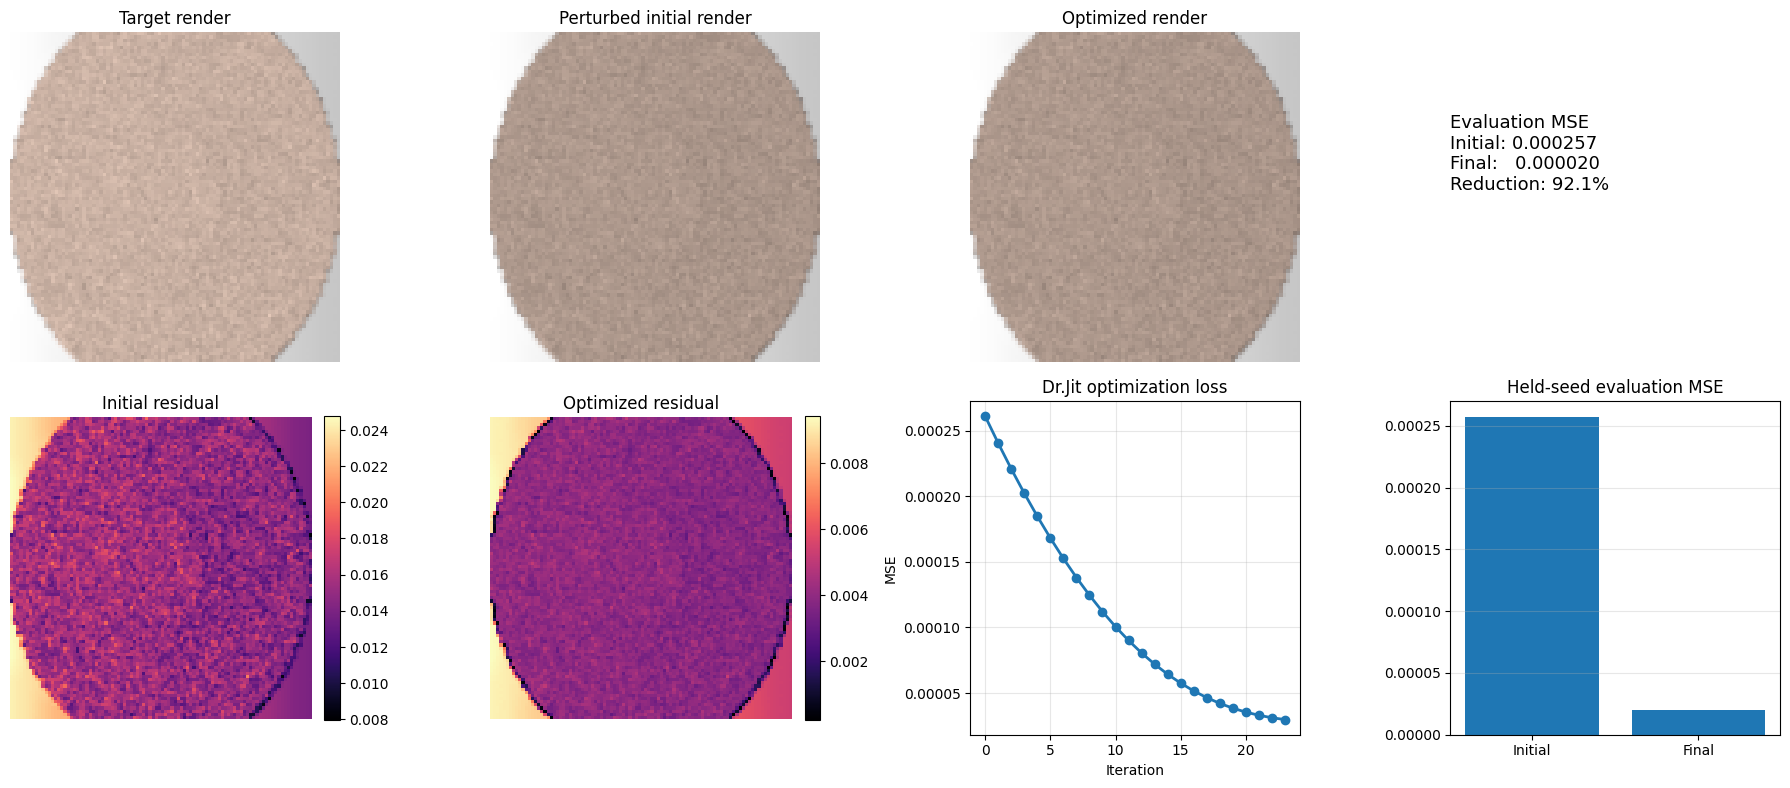

In [30]:
if mitsuba_payload["status"] == "completed":
    import mitsuba as mi
    mi.set_variant(mitsuba_config.variant)

    def load_exr(path):
        bitmap = mi.Bitmap(str(path))
        arr = np.array(bitmap, dtype=np.float32)
        if arr.ndim == 2:
            arr = np.repeat(arr[..., None], 3, axis=-1)
        if arr.shape[-1] > 3:
            arr = arr[..., :3]
        return np.nan_to_num(arr, nan=0.0, posinf=1.0, neginf=0.0)

    def tonemap(image):
        image = np.maximum(image, 0.0)
        scale = np.percentile(image, 99.0)
        if scale <= 1e-6:
            scale = 1.0
        return np.clip(image / scale, 0.0, 1.0) ** (1.0 / 2.2)

    mitsuba_target = load_exr(MITSUBA_OUTPUT_DIR / "target.exr")
    mitsuba_initial = load_exr(MITSUBA_OUTPUT_DIR / "initial.exr")
    mitsuba_optimized = load_exr(MITSUBA_OUTPUT_DIR / "optimized.exr")
    initial_residual = np.abs(mitsuba_target - mitsuba_initial).mean(axis=-1)
    optimized_residual = np.abs(mitsuba_target - mitsuba_optimized).mean(axis=-1)
    diagnostics = mitsuba_payload.get("diagnostics", {})

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes[0, 0].imshow(tonemap(mitsuba_target))
    axes[0, 0].set_title("Target render")
    axes[0, 1].imshow(tonemap(mitsuba_initial))
    axes[0, 1].set_title("Perturbed initial render")
    axes[0, 2].imshow(tonemap(mitsuba_optimized))
    axes[0, 2].set_title("Optimized render")
    axes[0, 3].axis("off")
    axes[0, 3].text(
        0.0,
        0.75,
        "Evaluation MSE\n"
        f"Initial: {diagnostics.get('initial_eval_mse', float('nan')):.6f}\n"
        f"Final:   {diagnostics.get('final_eval_mse', float('nan')):.6f}\n"
        f"Reduction: {100.0 * diagnostics.get('relative_mse_reduction', 0.0):.1f}%",
        fontsize=13,
        va="top",
    )

    heat0 = axes[1, 0].imshow(initial_residual, cmap="magma")
    axes[1, 0].set_title("Initial residual")
    heat1 = axes[1, 1].imshow(optimized_residual, cmap="magma")
    axes[1, 1].set_title("Optimized residual")
    axes[1, 2].plot(mitsuba_payload.get("losses", []), marker="o", linewidth=2)
    axes[1, 2].set_title("Dr.Jit optimization loss")
    axes[1, 2].set_xlabel("Iteration")
    axes[1, 2].set_ylabel("MSE")
    axes[1, 2].grid(True, alpha=0.3)
    axes[1, 3].bar(["Initial", "Final"], [diagnostics.get("initial_eval_mse", 0.0), diagnostics.get("final_eval_mse", 0.0)])
    axes[1, 3].set_title("Held-seed evaluation MSE")
    axes[1, 3].grid(True, axis="y", alpha=0.3)

    for ax in [axes[0, 0], axes[0, 1], axes[0, 2], axes[1, 0], axes[1, 1]]:
        ax.axis("off")
    fig.colorbar(heat0, ax=axes[1, 0], fraction=0.046, pad=0.04)
    fig.colorbar(heat1, ax=axes[1, 1], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
else:
    print("Mitsuba section skipped or failed:", mitsuba_payload["message"])


## 15. Mitsuba Parameter Evidence

These keys are the concrete scene variables optimized by Mitsuba/Dr.Jit. This is the clearest evidence that this notebook includes real differentiable rendering rather than only PyTorch image fitting.

In [31]:
print("Optimized differentiable keys:")
for key in mitsuba_payload.get("optimized_keys", []):
    print("  -", key)

print("\nConvergence diagnostics:")
for key, value in mitsuba_payload.get("diagnostics", {}).items():
    print(f"  - {key}: {value:.8f}")

print("\nFirst 30 traversed scene parameters:")
for key in mitsuba_payload.get("parameter_keys", [])[:30]:
    print("  -", key)


Optimized differentiable keys:
  - object_35317542912.bsdf.reflectance.data
  - object_35205109760.scale

Convergence diagnostics:
  - initial_eval_mse: 0.00025708
  - final_eval_mse: 0.00002033
  - absolute_mse_reduction: 0.00023675
  - relative_mse_reduction: 0.92092895

First 30 traversed scene parameters:
  - allow_thread_reordering
  - object_34929262592.near_clip
  - object_34929262592.far_clip
  - object_34929262592.shutter_open
  - object_34929262592.shutter_open_time
  - object_34929262592.film.size
  - object_34929262592.film.crop_size
  - object_34929262592.film.crop_offset
  - object_34929262592.x_fov
  - object_34929262592.principal_point_offset_x
  - object_34929262592.principal_point_offset_y
  - object_34929262592.to_world
  - object_35205109760.sampling_weight
  - object_35205109760.scale
  - object_35205109760.data
  - object_35205109760.to_world
  - object_35317542912.bsdf.reflectance.data
  - object_35317542912.bsdf.reflectance.to_uv
  - object_35317542912.silhouett

## 16. Where Everything Was Saved

In [32]:
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file() and path.suffix.lower() in {".png", ".gif", ".svg", ".json", ".csv", ".md", ".txt"}:
        print(path.relative_to(REPO_ROOT))

outputs/notebook_research_run/ablation_summary.md
outputs/notebook_research_run/config.json
outputs/notebook_research_run/input_metadata.json
outputs/notebook_research_run/mitsuba_drjit/mitsuba_inverse_summary.json
outputs/notebook_research_run/mitsuba_drjit/mitsuba_parameter_keys.json
outputs/notebook_research_run/mitsuba_drjit/scene/mitsuba_face_inverse_albedo.png
outputs/notebook_research_run/mitsuba_drjit/scene/mitsuba_face_inverse_envmap.png
outputs/notebook_research_run/mitsuba_drjit/scene/mitsuba_face_inverse_metadata.json
outputs/notebook_research_run/phase1/diagnostics/component_statistics.json
outputs/notebook_research_run/phase1/diagnostics/decomposition_grid.png
outputs/notebook_research_run/phase1/diagnostics/diagnostic_summary.json
outputs/notebook_research_run/phase1/diagnostics/diagnostic_summary.md
outputs/notebook_research_run/phase1/diagnostics/lighting_coefficients.json
outputs/notebook_research_run/phase1/diagnostics/lighting_coefficients.svg
outputs/notebook_resea